In [41]:
# Step 1: Load & Explore Dataset

import pandas as pd
import os

project_root=os.path.dirname(os.path.dirname(os.path.abspath(__file__))) if '__file__' in globals() else os.path.dirname(os.getcwd())

# Load dataset
file_path = os.path.join(project_root,"data","synthetic_asthma_dataset.csv")
df = pd.read_csv(file_path)

# Quick overview
print(" Dataset Shape:", df.shape)
print("\n First 5 Rows:\n", df.head())

# Check column info
print("\n Column Info:\n")
print(df.info())


# Data quality checks

# Missing values
print("\n Missing Values:\n", df.isnull().sum())

# Duplicates
print("\n Duplicate Rows:", df.duplicated().sum())

# Target distribution
print("\n Target Distribution:\n", df["Has_Asthma"].value_counts())
print("\n Target Distribution (%):\n", df["Has_Asthma"].value_counts(normalize=True))


# Summary statistics (numerical)
print("\n Summary Statistics:\n", df.describe())


# Drop irrelevant columns (keep only features + target)
df_clean = df.drop(columns=["Patient_ID", "Asthma_Control_Level"], errors="ignore")

print("\nCleaned dataset shape:", df_clean.shape)


 Dataset Shape: (10000, 17)

 First 5 Rows:
    Patient_ID  Age  Gender   BMI Smoking_Status  Family_History Allergies  \
0  ASTH100000   52  Female  27.6         Former               1       NaN   
1  ASTH100001   15    Male  24.6         Former               0      Dust   
2  ASTH100002   72  Female  17.6          Never               0       NaN   
3  ASTH100003   61    Male  16.8          Never               0  Multiple   
4  ASTH100004   21    Male  30.2          Never               0       NaN   

  Air_Pollution_Level Physical_Activity_Level Occupation_Type Comorbidities  \
0            Moderate               Sedentary         Outdoor      Diabetes   
1                 Low                Moderate          Indoor          Both   
2            Moderate                Moderate          Indoor           NaN   
3                High               Sedentary         Outdoor          Both   
4            Moderate                  Active          Indoor           NaN   

   Medication_Adh

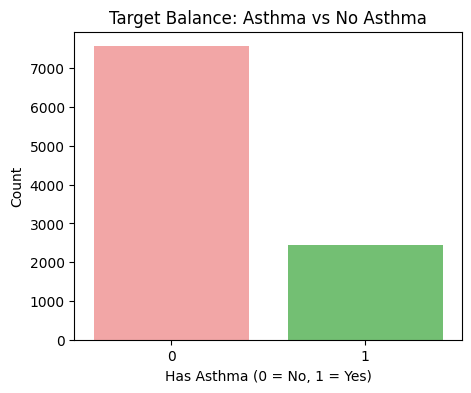

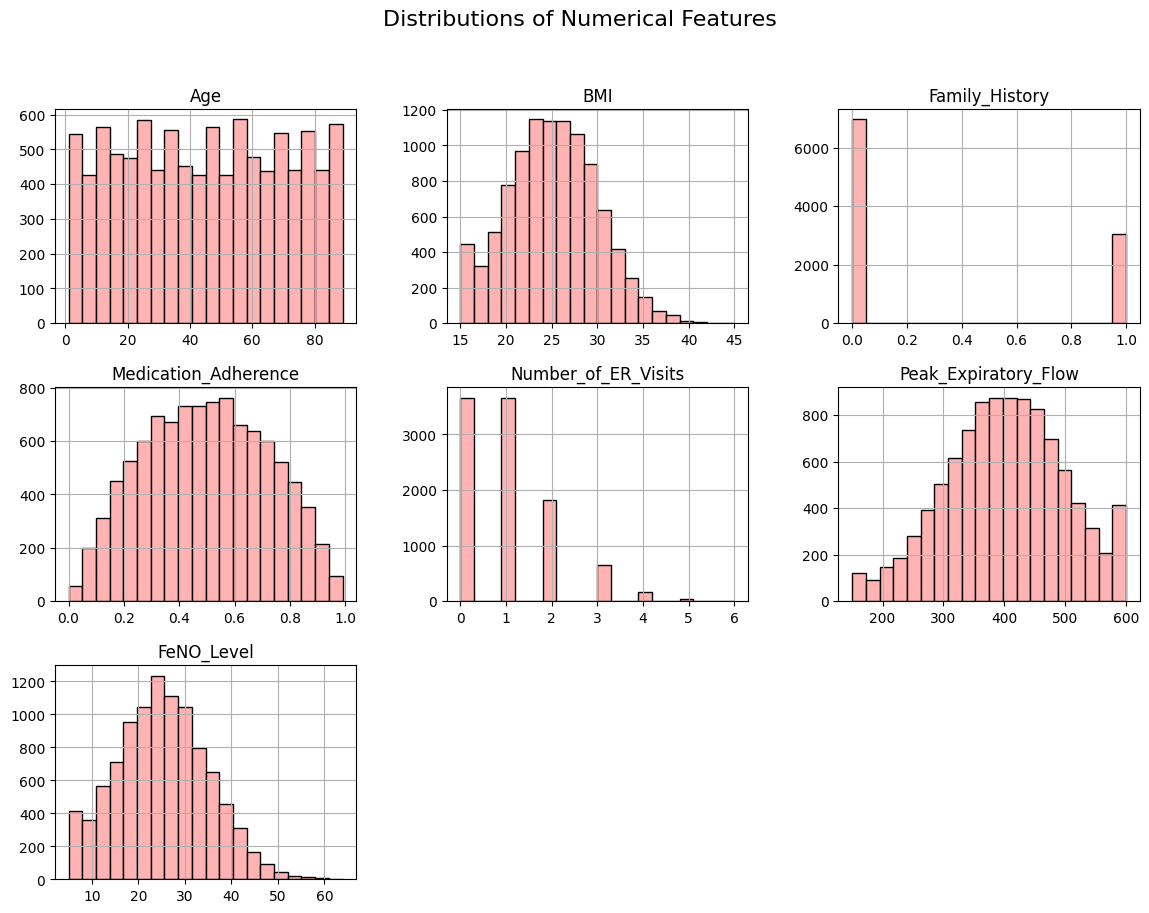

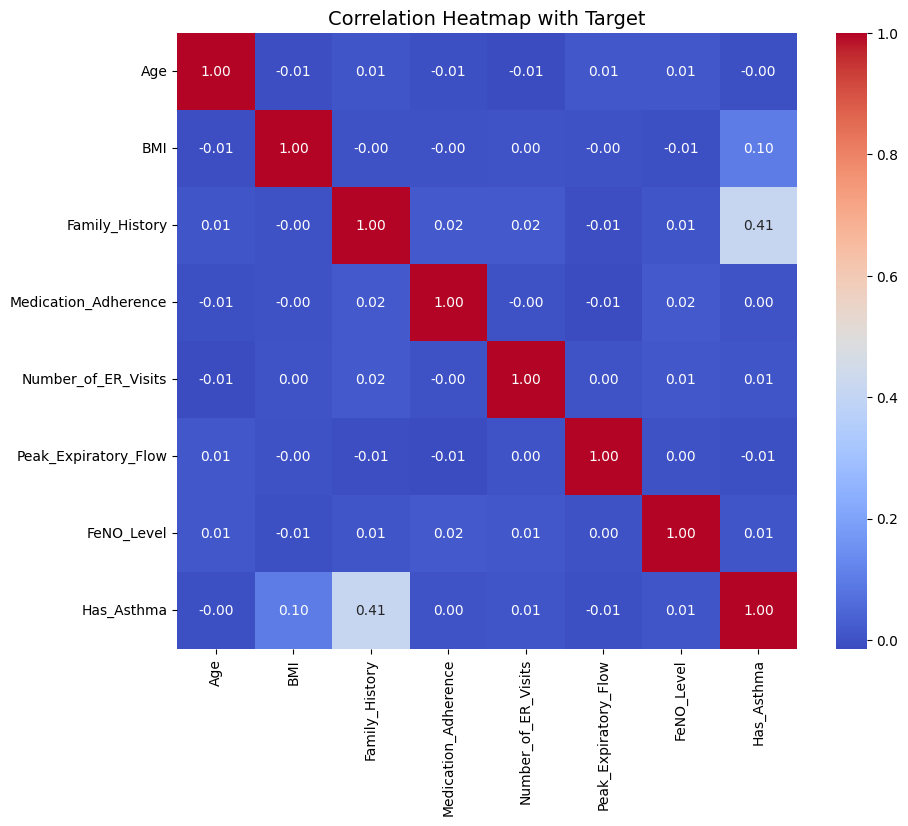

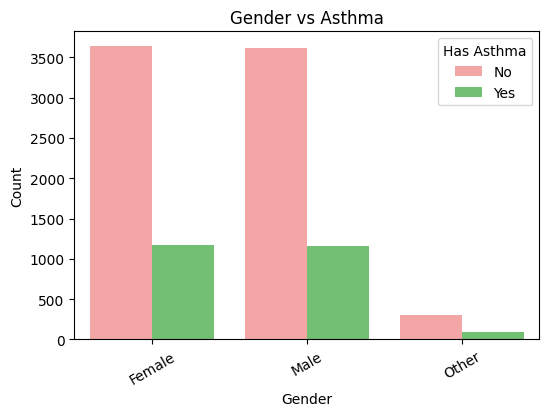

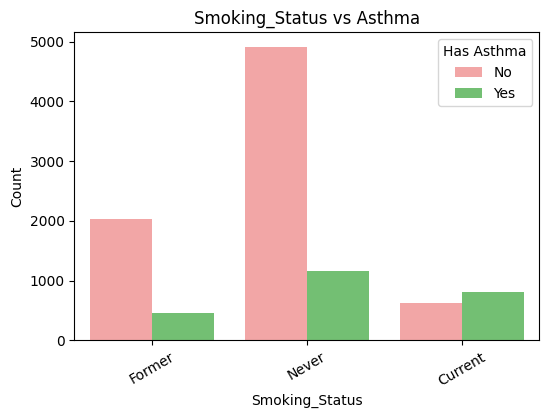

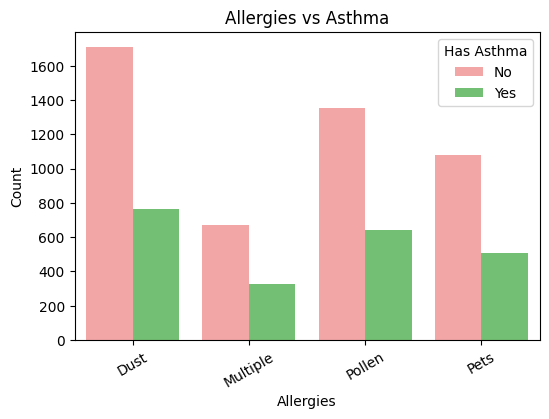

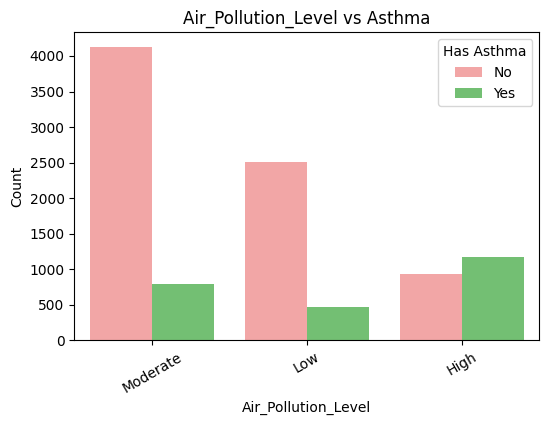

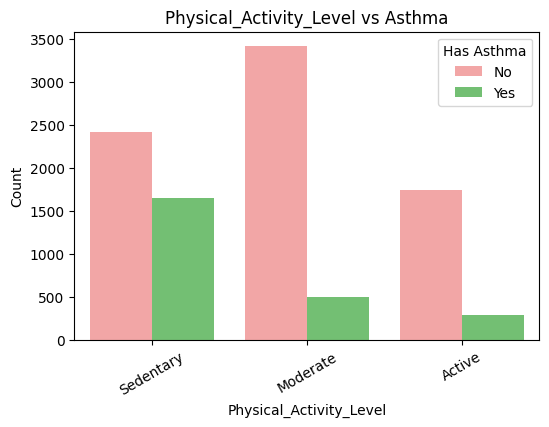

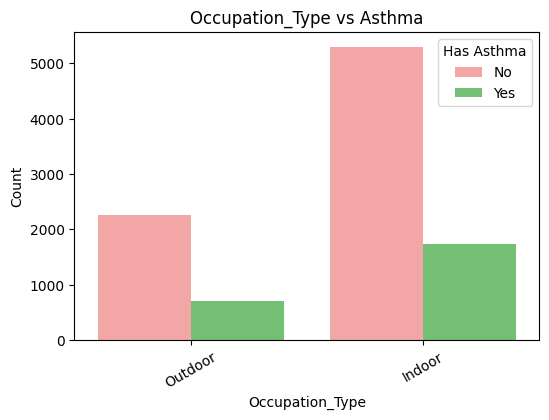

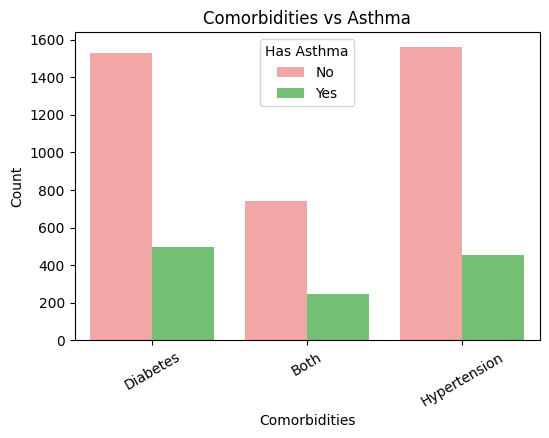

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Custom pink & green palette
custom_palette = {0: "#ff9999", 1: "#66cc66"}

# 1. Target balance (class distribution)
plt.figure(figsize=(5,4))
sns.countplot(x="Has_Asthma", hue="Has_Asthma", data=df_clean, palette=custom_palette, legend=False)
plt.title("Target Balance: Asthma vs No Asthma")
plt.xlabel("Has Asthma (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# 2. Histograms for numerical features
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.drop("Has_Asthma")

df_clean[num_cols].hist(bins=20, figsize=(14, 10), color="#ffb3b3", edgecolor="black")
plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.show()

# 3. Correlation heatmap (numerical features only)
plt.figure(figsize=(10,8))
corr = df_clean[num_cols.tolist() + ["Has_Asthma"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap with Target", fontsize=14)
plt.show()

# 4. Categorical features vs Target
cat_cols = df_clean.select_dtypes(include=["object"]).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Has_Asthma", data=df_clean, palette=custom_palette)
    plt.title(f"{col} vs Asthma")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Has Asthma", labels=["No", "Yes"])
    plt.xticks(rotation=30)
    plt.show()


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def preprocess_data(df, target_col="Has_Asthma"):
    # Separate features & target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # Identify column types
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["object"]).columns

    # Pipelines for preprocessing
    num_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    # Column transformer: applies pipelines to correct cols
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_pipeline, num_cols),
            ("cat", cat_pipeline, cat_cols)
        ]
    )

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    return X_train, X_test, y_train, y_test, preprocessor


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Get train/test sets + preprocessor
X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df_clean)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Store trained pipelines
trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe
    print(f"{name} trained successfully")




Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


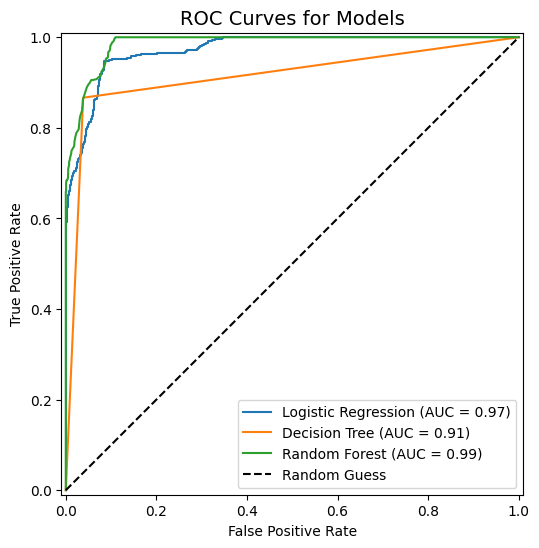

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Plot ROC curves for all models
plt.figure(figsize=(8,6))

for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(
        model, X_test, y_test, name=name, ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")  # diagonal line
plt.title("ROC Curves for Models", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


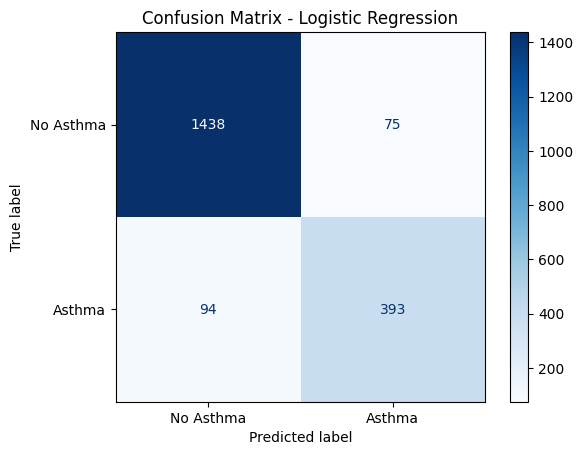

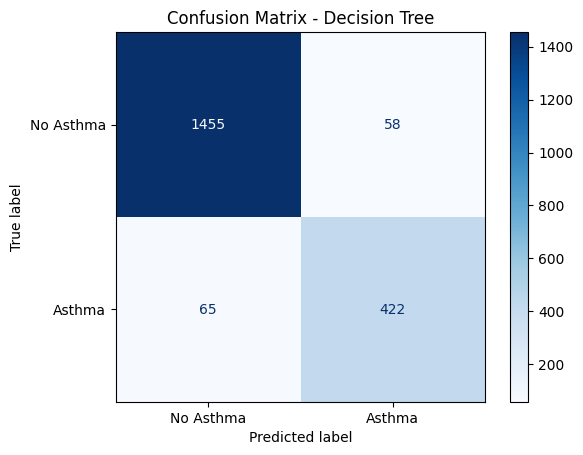

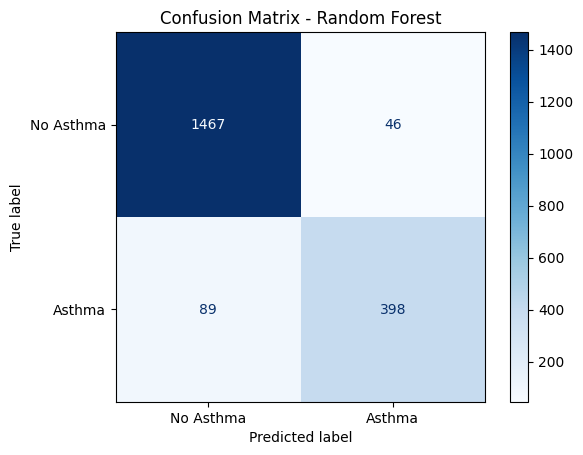

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrices for all model-
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Asthma", "Asthma"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

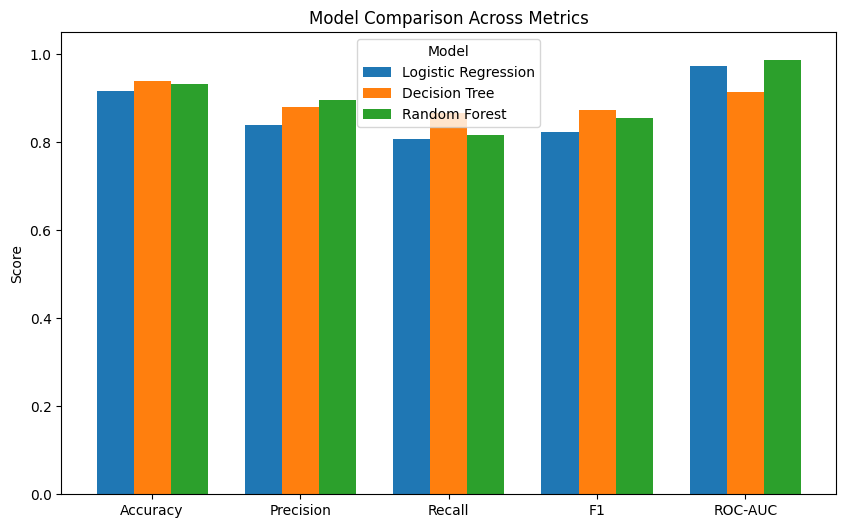

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Collect metrics for each model
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
results = {metric: [] for metric in metrics}
model_names = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    model_names.append(name)
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred))
    results["Recall"].append(recall_score(y_test, y_pred))
    results["F1"].append(f1_score(y_test, y_pred))
    results["ROC-AUC"].append(roc_auc_score(y_test, y_prob) if y_prob is not None else 0)

# Plot side-by-side bars
x = range(len(metrics))
bar_width = 0.25

plt.figure(figsize=(10,6))

for i, name in enumerate(model_names):
    scores = [results[m][i] for m in metrics]
    plt.bar([pos + i*bar_width for pos in x], scores, width=bar_width, label=name)

plt.xticks([pos + bar_width for pos in x], metrics)
plt.ylabel("Score")
plt.title("Model Comparison Across Metrics")
plt.ylim(0, 1.05)
plt.legend(title="Model")
plt.show()


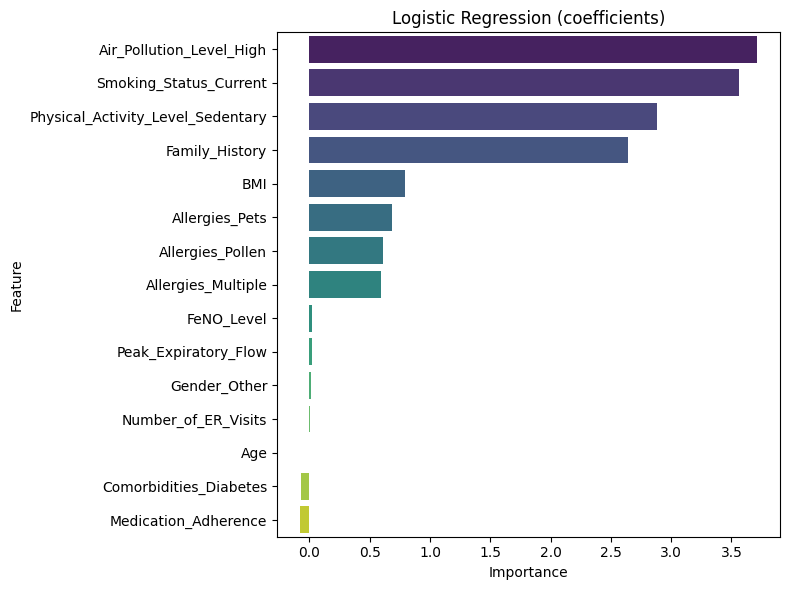

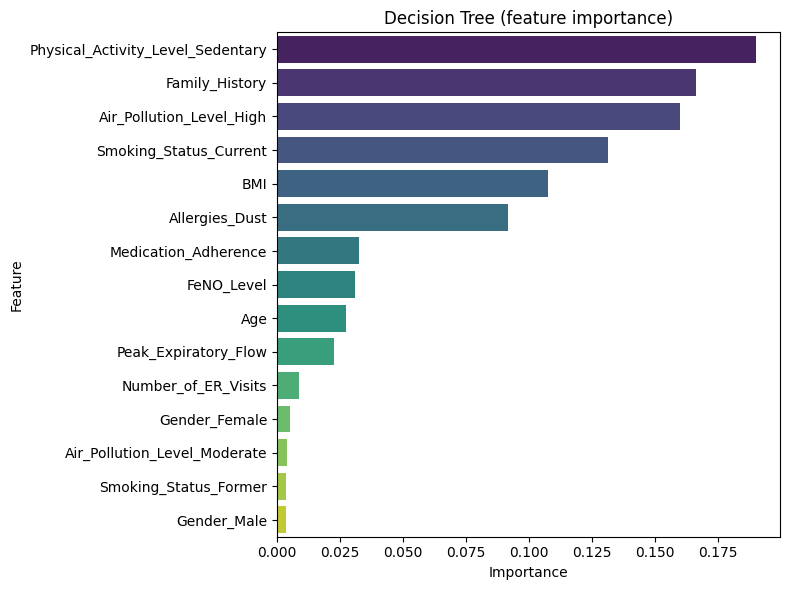

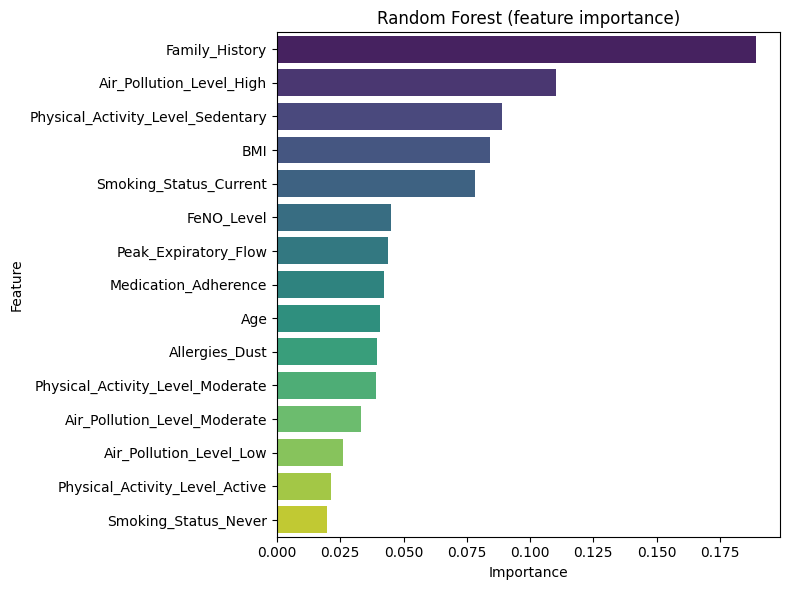

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_feature_names(preprocessor):
    """Extract feature names from ColumnTransformer"""
    # Numeric features
    num_features = preprocessor.transformers_[0][2]

    # Categorical features (after one-hot encoding)
    cat_features = preprocessor.transformers_[1][1] \
        .named_steps["onehot"].get_feature_names_out(preprocessor.transformers_[1][2])

    return np.concatenate([num_features, cat_features])


def plot_feature_importances(trained_models, preprocessor, top_n=15):
    feature_names = get_feature_names(preprocessor)

    for name, model in trained_models.items():
        clf = model.named_steps["classifier"]

        # Logistic Regression
        if name == "Logistic Regression":
            importances = clf.coef_[0]
            title = f"{name} (coefficients)"

        # Tree-based models
        else:
            importances = clf.feature_importances_
            title = f"{name} (feature importance)"

        # Put into dataframe
        fi_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values("Importance", ascending=False).head(top_n)

        # Plot
        plt.figure(figsize=(8, 6))
        sns.barplot(
            x="Importance",
            y="Feature",
            data=fi_df,
            hue="Feature",
            palette="viridis",
            legend=False
        )
        plt.title(title)
        plt.tight_layout()
        plt.show()


# Call the function
plot_feature_importances(trained_models, preprocessor, top_n=15)


In [49]:
import os
import joblib

# Always resolve project root (two levels up from this notebook file)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
model_dir = os.path.join(project_root, "models")
os.makedirs(model_dir, exist_ok=True)

# Save model
best_model = trained_models["Random Forest"]
model_path = os.path.join(model_dir, "best_model.pkl")
joblib.dump(best_model, model_path)

print(f"Random Forest pipeline saved as {model_path}")





Random Forest pipeline saved as c:\Users\Hp\OneDrive\Desktop\asthama_prediction_project\models\best_model.pkl


In [50]:
print("Features in df_clean:\n", df_clean.drop(columns=["Has_Asthma"]).columns.tolist())
print("\nNumerical features:\n", df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist())
print("\nCategorical features:\n", df_clean.select_dtypes(include=["object"]).columns.tolist())


Features in df_clean:
 ['Age', 'Gender', 'BMI', 'Smoking_Status', 'Family_History', 'Allergies', 'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type', 'Comorbidities', 'Medication_Adherence', 'Number_of_ER_Visits', 'Peak_Expiratory_Flow', 'FeNO_Level']

Numerical features:
 ['Age', 'BMI', 'Family_History', 'Medication_Adherence', 'Number_of_ER_Visits', 'Peak_Expiratory_Flow', 'FeNO_Level', 'Has_Asthma']

Categorical features:
 ['Gender', 'Smoking_Status', 'Allergies', 'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type', 'Comorbidities']
